In [1]:
import numpy as np 
import pandas as pd

import os
import cv2 as cv
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
all_0 = "C:/Users/SNEKHA/Desktop/C-NMC_Leukemia/training_data/fold_0/all"
all_1 = "C:/Users/SNEKHA/Desktop/C-NMC_Leukemia/training_data/fold_1/all"
all_2 = "C:/Users/SNEKHA/Desktop/C-NMC_Leukemia/training_data/fold_2/all"

hem_0 = "C:/Users/SNEKHA/Desktop/C-NMC_Leukemia/training_data/fold_0/hem"
hem_1 = "C:/Users/SNEKHA/Desktop/C-NMC_Leukemia/training_data/fold_1/hem"
hem_2 = "C:/Users/SNEKHA/Desktop/C-NMC_Leukemia/training_data/fold_2/hem"

In [3]:
def get_path_image(folder):
    image_paths = []
    image_fnames = os.listdir(folder) 
    for img_id in range(len(image_fnames)):
        img = os.path.join(folder,image_fnames[img_id])
        image_paths.append(img)
    
    return image_paths

In [4]:
img_data = []

for i in [all_0,all_1,all_2,hem_0,hem_1,hem_2]:
    paths = get_path_image(i)
    img_data.extend(paths)
print(len(img_data))

10661


In [5]:
data = {"img_data":img_data,
        "labels":[np.nan for x in range(len(img_data))]}

data = pd.DataFrame(data) 

In [6]:
data["labels"][0:7272] = 1 # ALL
data["labels"][7272:10661] = 0 # HEM

C:\Users\SNEKHA\AppData\Local\Temp\ipykernel_22052\2481703241.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["labels"][0:7272] = 1 # ALL
C:\Users\SNEKHA\AppData\Local\Temp\ipykernel_22052\2481703241.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["labels"][7272:10661] = 0 # HEM


In [7]:
data["labels"] = data["labels"].astype("int64")

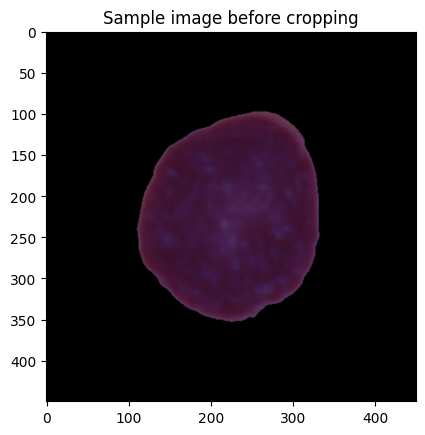

In [8]:
image = cv.imread(data["img_data"][1000])
plt.imshow(image)
plt.title("Sample image before cropping")
plt.show()

In [9]:
img_list = []
for i in range(len(img_data)):
    image = cv.imread(data["img_data"][i])
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    thresh = cv.threshold(gray, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)[1]

    result = cv.bitwise_and(image, image, mask=thresh)
    result[thresh==0] = [255,255,255] 
    (x, y, z_) = np.where(result > 0)
    mnx = (np.min(x))
    mxx = (np.max(x))
    mny = (np.min(y))
    mxy = (np.max(y))
    crop_img = image[mnx:mxx,mny:mxy,:]
    crop_img_r = cv.resize(crop_img, (224,224))
    img_list.append(crop_img_r)

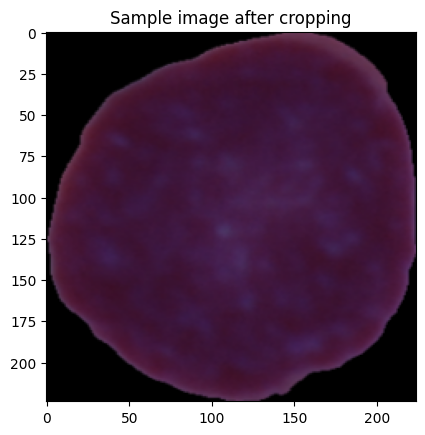

In [10]:
plt.imshow(img_list[1000])
plt.title("Sample image after cropping")
plt.show()

In [11]:
from tensorflow.keras.applications import ResNet50, ResNet101
from keras.applications.vgg19 import VGG19
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from tensorflow.keras.applications.resnet50 import preprocess_input

In [12]:
def feature_extract(model):
    if model == "VGG19": model = VGG19(weights='imagenet',include_top=False, pooling="avg")
    elif model == "ResNet50": model = ResNet50(weights='imagenet',include_top=False,pooling="avg")
    elif model == "ResNet101": model = ResNet101(weights='imagenet',include_top=False,pooling="avg")
    return model

In [13]:
model = feature_extract("ResNet50") # or "VGG19", "ResNet101"

In [14]:
features_list = []
for i in range(len(img_list)):
            
    image = img_list[i].reshape(-1, 224, 224, 3) 
    image = preprocess_input(image)
    
    """
    # Reshaping when VGG19 model is selected
    features = model.predict(image).reshape(512,)
    """

    #Reshaping  when ResNet50 or ResNet101 model is selected
    features = model.predict(image).reshape(2048,)
    
    features_list.append(features)

1/1 [==============================] - 0s 283ms/step


In [15]:
features_df = pd.DataFrame(features_list)

In [16]:
features_df["labels"] = data["labels"]

In [17]:
x = features_df.drop(['labels'], axis = 1)
y = features_df.loc[:,"labels"].values

In [18]:
x

,0,1,2,3,4,5,6,7,8,9,...,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047
0,5.253783,0.042580,0.051578,0.008029,0.057129,0.004375,0.227441,0.003590,0.005153,0.012571,...,0.561743,0.071850,0.011782,1.103318,0.290165,0.000000,0.491152,0.112431,0.000000,0.310525
1,8.079423,0.011574,0.053684,0.186905,0.000000,0.000000,0.042724,0.000000,0.574390,0.006339,...,0.209751,0.000000,0.000000,1.683905,0.019044,0.000000,0.020532,0.196671,0.081518,0.548087
2,6.266923,0.219213,0.018837,0.008474,0.000000,0.000000,0.224284,0.000000,0.000000,0.012756,...,0.137901,0.000000,0.000000,0.857915,0.159714,0.044442,0.702736,0.286233,0.070878,0.547750
3,6.486918,0.000000,0.020409,0.164188,0.000000,0.039742,0.098523,0.000000,0.136671,0.093839,...,0.383021,0.041494,0.000000,2.700690,0.249594,0.000000,0.152288,0.462613,0.330928,0.708187
4,5.148223,0.060939,0.000000,0.106593,0.000000,0.036498,0.074916,0.095883,0.034331,0.008917,...,0.175660,0.030387,0.190983,0.357074,0.000000,0.015142,0.291253,0.187770,0.045915,0.046781
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10656,5.135459,0.023519,0.000000,0.013403,0.095962,0.044262,0.067926,0.006756,0.088878,0.000000,...,0.048080,0.036390,0.021044,0.119651,0.045240,0.000000,0.611429,0.220862,0.202260,1.137161
10657,5.458828,0.028126,0.000000,0.173168,0.000000,0.006622,0.014663,0.024785,0.046513,0.125333,...,0.638946,0.064940,0.215364,0.566119,0.000000,0.000000,0.363782,0.380672,1.268512,0.600716
10658,5.933909,0.000000,0.000000,0.069616,0.000000,0.110708,0.000000,0.000000,0.008634,0.000000,...,0.152811,0.000000,0.011421,0.638716,0.095322,0.000000,0.569343,0.919506,0.474505,0.909486
10659,5.647941,0.059169,0.000000,0.116159,0.007541,0.000000,0.112060,0.000000,0.081253,0.293994,...,1.008240,0.030306,0.088561,0.514058,0.000000,0.000000,0.012645,0.703623,0.492333,1.778769


In [19]:
print(f"Number of features before feature selection: {x.shape[1]}")

Number of features before feature selection: 2048


In [20]:

y

array([1, 1, 1, ..., 0, 0, 0], dtype=int64)

In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(x)
x_ = scaler.transform(x)

In [22]:
x_ = pd.DataFrame(x_)

In [23]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

def anova_fs():
    
    selector = SelectKBest(f_classif, k=500) # k is number of features
    selector.fit(x_, y)

    cols = selector.get_support(indices=True)
    anova_x = x_[cols]
    return anova_x

In [24]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

def RFE_fs():
    rfe_selector = RFE(estimator=RandomForestClassifier())
    rfe_selector.fit(x_, y)
    
    rfe_support = rfe_selector.get_support()
    rfe_feature = x_.loc[:,rfe_support].columns.tolist()
    
    rfe_x = x_[rfe_feature]
    return rfe_x

In [25]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

def rf_fs():
    embeded_rf_selector = SelectFromModel(RandomForestClassifier(n_estimators=200, random_state=5), threshold='1.25*median')
    embeded_rf_selector.fit(x, y)
    
    embeded_rf_support = embeded_rf_selector.get_support()
    embeded_rf_feature = x.loc[:,embeded_rf_support].columns.tolist()
    
    rf_x = x[embeded_rf_feature]
    return rf_x

In [26]:
fs_x = rf_fs() # feature selection methods "anova_fs", "RFE_fs"

In [27]:
print(f"Number of features after feature selection: {fs_x.shape[1]}")

Number of features after feature selection: 630


In [28]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(fs_x, y, test_size = 0.2, random_state = 42)

In [31]:
pip install xgboost

   ---------------------------------------- 0.0/99.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/99.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/99.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/99.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/99.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/99.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/99.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/99.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/99.8 MB 65.6 kB/s eta 0:25:20
   ---------------------------------------- 0.0/99.8 MB 65.6 kB/s eta 0:25:20
   ---------------------------------------- 0.0/99.8 MB 65.6 kB/s eta 0:25:20
Note: you may need to restart the kernel to use updated packages.
   ---------------------------------------- 0.0/99.8 MB 65.6 kB/s eta 0:25:20
   ---------------------------------------- 0.0/99.8 MB 65.6 k

   ------ --------------------------------- 16.8/99.8 MB 401.2 kB/s eta 0:03:27
   ------ --------------------------------- 16.8/99.8 MB 401.2 kB/s eta 0:03:27
   ------ --------------------------------- 16.8/99.8 MB 394.9 kB/s eta 0:03:30
   ------ --------------------------------- 16.8/99.8 MB 394.9 kB/s eta 0:03:30
   ------ --------------------------------- 16.8/99.8 MB 394.9 kB/s eta 0:03:30
   ------ --------------------------------- 16.8/99.8 MB 394.9 kB/s eta 0:03:30
   ------ --------------------------------- 16.8/99.8 MB 394.9 kB/s eta 0:03:30
   ------ --------------------------------- 16.8/99.8 MB 394.9 kB/s eta 0:03:30
   ------ --------------------------------- 16.9/99.8 MB 391.1 kB/s eta 0:03:32
   ------ --------------------------------- 16.9/99.8 MB 390.6 kB/s eta 0:03:33
   ------ --------------------------------- 16.9/99.8 MB 390.4 kB/s eta 0:03:33
   ------ --------------------------------- 16.9/99.8 MB 389.7 kB/s eta 0:03:33
   ------ ------------------------------

In [29]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score,confusion_matrix,classification_report

In [30]:
from xgboost import XGBClassifier
model = XGBClassifier()
model.fit(x_train, y_train)
model.score(x_test, y_test)

0.8738865447726207

In [31]:
predicted =model.predict(x_test)
print(confusion_matrix(y_test,predicted))
print(accuracy_score(y_test,predicted))
print(classification_report(y_test,predicted))

[[ 463  215]
 [  54 1401]]
0.8738865447726207
              precision    recall  f1-score   support

           0       0.90      0.68      0.77       678
           1       0.87      0.96      0.91      1455

    accuracy                           0.87      2133
   macro avg       0.88      0.82      0.84      2133
weighted avg       0.88      0.87      0.87      2133



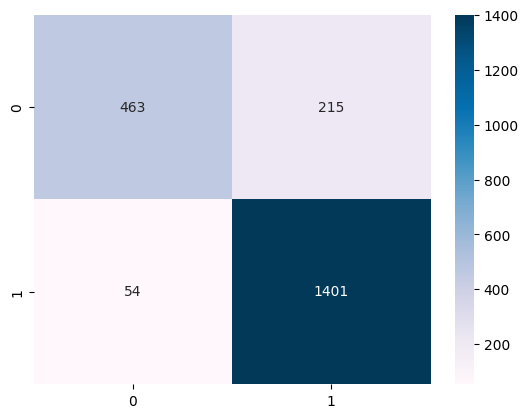

In [32]:
cf_matrix = confusion_matrix(y_test, predicted)
sns.heatmap(cf_matrix, cmap="PuBu", annot=True, fmt='.0f')
plt.show()

In [42]:
param_grid_xgboost = { 'scale_pos_weight':[150],
             'max_depth':[1],
             'n_estimators':[60],
             'colsample_bylevel':[0.5,],
             'colsample_bynode':[0.5],
             'colsample_bytree':[0.4],
             'learning_rate':[0.001,0.01,0.1]}
    
print(param_grid_xgboost)

{'scale_pos_weight': [150], 'max_depth': [1], 'n_estimators': [60], 'colsample_bylevel': [0.5], 'colsample_bynode': [0.5], 'colsample_bytree': [0.4], 'learning_rate': [0.001, 0.01, 0.1]}


In [ ]:
XGBoost_grid = GridSearchCV(estimator=RandomForestClassifier(), param_grid=param_grid_rf, cv= 5)
RF_grid.fit(x_train, y_train)

In [48]:
from sklearn.model_selection import GridSearchCV,StratifiedKFold,cross_val_score
kfold=StratifiedKFold(n_splits=2,shuffle=True,random_state=42)
def grid_search(params, model=XGBClassifier(random_state=42,scale_pos_weight=1000)):
    grid=GridSearchCV(model,params,cv=kfold,scorinng='recall')
    grid.fit(x_train,y_train)
    
    print('Best params:',grid.best_params_)
    print('Best score:',grid.best_score_)

In [49]:
param_grid_xgboost = { 'scale_pos_weight':[150],
             'max_depth':[1],
             'n_estimators':[60],
             'colsample_bylevel':[0.5,],
             'colsample_bynode':[0.5],
             'colsample_bytree':[0.4],
             'learning_rate':[0.001,0.01,0.1]}
    
print(param_grid_xgboost)

{'scale_pos_weight': [150], 'max_depth': [1], 'n_estimators': [60], 'colsample_bylevel': [0.5], 'colsample_bynode': [0.5], 'colsample_bytree': [0.4], 'learning_rate': [0.001, 0.01, 0.1]}


In [52]:
#Build XGBoost model - with accuracy score
model=XGBClassifier(scale_pos_weight=400,
                    max_depth=9,
                    n_estimators=670,
                    colsample_bylevel=0.5,
                    colsample_bynode=0.5,
                    colsample_bytree=0.4,
                    learning_rate=0.0001,
                    random_state=42)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
                    


0.6821378340365682
[[   0  678]
 [   0 1455]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       678
           1       0.68      1.00      0.81      1455

    accuracy                           0.68      2133
   macro avg       0.34      0.50      0.41      2133
weighted avg       0.47      0.68      0.55      2133



C:\Users\SNEKHA\anaconda3\envs\keras_env\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\SNEKHA\anaconda3\envs\keras_env\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\SNEKHA\anaconda3\envs\keras_env\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(r

In [51]:
# XGBoost
import xgboost as xgb
params_xgb ={'n_estimators': 500,
            'max_depth': 16}

model_xgb = xgb.XGBClassifier(**params_xgb)
model_xgb.fit(x_train,y_train)
predicted = model_xgb.predict(x_test)
score =model_xgb.score(x_test, y_test)
xgb_score_ = np.mean(score)

print('Accuracy : %.3f' % (xgb_score_))

Accuracy : 0.872


In [53]:
from sklearn.linear_model import LogisticRegression

params_lr = {'penalty': 'l1', 'solver':'liblinear'}

model_lr = LogisticRegression(**params_lr)
model_lr.fit(x_train,y_train)
predicted = model_lr.predict(x_test)
score =model_lr.score(x_test, y_test)
lr_score_ = np.mean(score)

print('Accuracy : %.3f' % (lr_score_))

Accuracy : 0.859


In [1]:
from tabulate import tabulate

table=[['Model','Accuracy','precision','recall','f1_score','Weighted f1_score'],
       [ 'SVM',0.902,0.905,0.955,0.929,0.899],
       ['XGBoost',0.872,0.90,0.68,0.87],
       ['RandomForest',0.84,0.83,0.75,0.82],
      ['KNN',0.82,0.82,0.94,0.8,0.817],
        ['NaiveBayes',0.762,0.846,0.795,0.820,0.765]]
print(tabulate(table))

------------  --------  ---------  ------  --------  -----------------
Model         Accuracy  precision  recall  f1_score  Weighted f1_score
SVM           0.902     0.905      0.955   0.929     0.899
XGBoost       0.872     0.9        0.68    0.87
RandomForest  0.84      0.83       0.75    0.82
KNN           0.82      0.82       0.94    0.8       0.817
NaiveBayes    0.762     0.846      0.795   0.82      0.765
------------  --------  ---------  ------  --------  -----------------


In [2]:
pip install tabulate

Note: you may need to restart the kernel to use updated packages.
